# 🤖 Phase 2.1: Semantic Classifier (Word2Vec & Logistic Regression)

## 🏗 Overview: Word Embeddings (Word2Vec)
This phase utilizes **Word Embeddings** to represent words as dense vectors, capturing semantic meaning where similar words are positioned closely. Word2Vec will be trained on our corpus.

## 🔎 Approach: Semantic Classification
We will train a **Logistic Regression** model using these Word2Vec semantic representations to classify articles, comparing its performance against previous count-based models.

In [2]:
# 1. Environment Setup (Colab/Local Detection)
import os
import sys

# Silent installation of missing requirements for Colab
if 'google.colab' in sys.modules:
    !pip install -q gensim scikit-learn matplotlib seaborn
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/Project 2/project-nlp-challenge'
    print("Colab Environment detected. Google Drive mounted.")
else:
    BASE_PATH = '.'
    print("💻 Local Environment detected.")

# 2. Main Library Imports
import pandas as pd
import numpy as np
import joblib
import nltk
import re
import string
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 3. NLP Resource Downloads
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# 4. Folder Preparation (Ensure folders exist in Drive)
os.makedirs(os.path.join(BASE_PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, 'dataset'), exist_ok=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 104.3 MB/s eta 0:00:00
Mounted at /content/drive
Colab Environment detected. Google Drive mounted.


## 1. Data Ingestion
We load our cleaned datasets.

In [3]:
# Load the stratified datasets from Step 1
train_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/train.csv'))
test_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/test.csv'))

print(f"Data Loaded. Train Size: {train_df.shape}, Test Size: {test_df.shape}")


Data Loaded. Train Size: (31953, 7), Test Size: (7989, 7)


## 2. Word2Vec Embedding Strategy
We train a customized Word2Vec model on our tokenized corpus to map the words into a 100-dimensional semantic space.

In [4]:
# Tokenize the cleaned text (splitting by space as it's already pre-cleaned)
sentences = [str(row).split() for row in train_df['cleaned_text']]

# Train the Word2Vec model on our corpus
print("Training Word2Vec... (semantic learning in progress)")
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# Persist the embedding model for future use
joblib.dump(w2v_model, os.path.join(BASE_PATH, 'models/word2vec_model.joblib'))
print("Word2Vec Model Trained & Saved.")

Training Word2Vec... (semantic learning in progress)
Word2Vec Model Trained & Saved.


## 3. Transformation: Averaging Vectors
To represent an entire article, we average the vectors of every word it contains.

In [5]:
def document_vector(doc, model):
    # Only use words that exist in the Word2Vec vocabulary
    words = [w for w in str(doc).split() if w in model.wv.index_to_key]
    if not words:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[words], axis=0)

# Generate dense semantic vectors for train and test sets
print("Generating document vectors... (summarizing semantic space)")
X_train_w2v = np.vstack(train_df['cleaned_text'].apply(lambda d: document_vector(d, w2v_model)))
X_test_w2v = np.vstack(test_df['cleaned_text'].apply(lambda d: document_vector(d, w2v_model)))
y_train = train_df['label']
y_test = test_df['label']

print("Dense Semantic Vectors Generated.")


Generating document vectors... (summarizing semantic space)
Dense Semantic Vectors Generated.


## 4. Semantic Classifier Training
Training Logistic Regression on our Word2Vec dense vectors. Numbers instead of counts.


In [6]:
# Using standard Logistic Regression on the W2V vectors
lr_w2v_model = LogisticRegression(max_iter=1000)
lr_w2v_model.fit(X_train_w2v, y_train)

# Save the trained classifier
joblib.dump(lr_w2v_model, os.path.join(BASE_PATH, 'models/lr_word2vec_classifier.joblib'))
print("Semantic Classifier (W2V + LR) Trained & Persistent.")


Semantic Classifier (W2V + LR) Trained & Persistent.


## 5. Evaluation
How much does 'Meaning' w2v improve accuracy compared to 'Count' ?


📊 Semantic Model Performance (Word2Vec):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3989
           1       0.98      0.98      0.98      4000

    accuracy                           0.98      7989
   macro avg       0.98      0.98      0.98      7989
weighted avg       0.98      0.98      0.98      7989





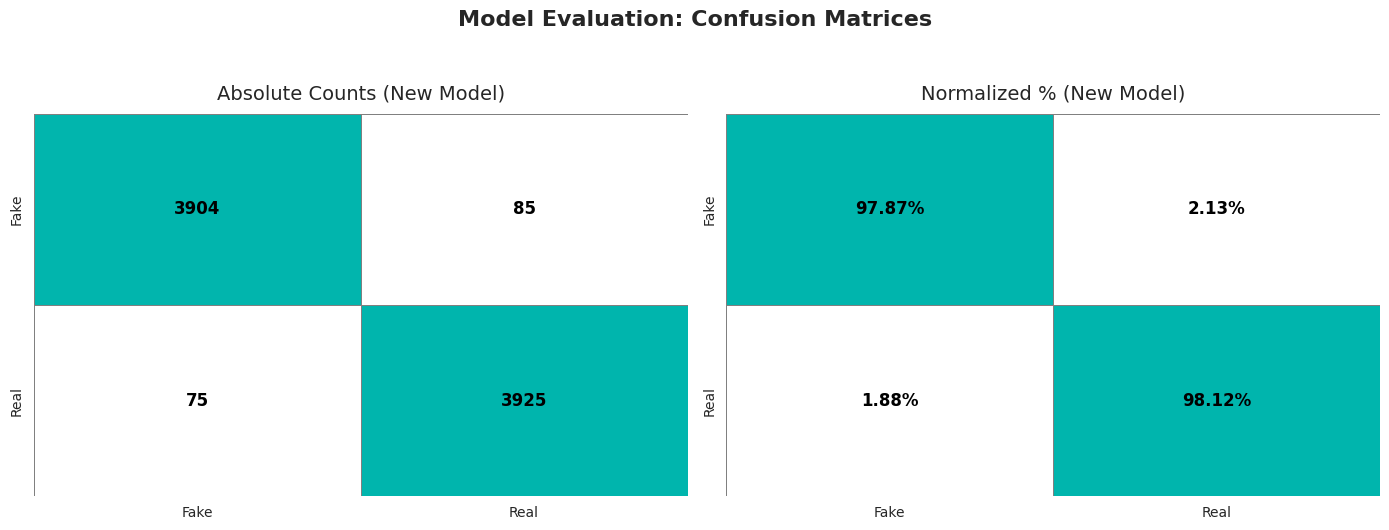




🎯 TOP SEMANTIC DRIVE (Words that the model associates with REAL NEWS):
['reuters' 'reporters' 'capital' 'said' 'amid' '“' 'former' 'nov'
 'expressed' 'oct']

🚩 TOP SEMANTIC DRIVE (Words that the model associates with FAKE NEWS):
['image' 'watch' 'hannity' 'breitbart' 'video' 'fox' 'story' 'spicer'
 'report' 'pretty']


In [7]:
import matplotlib.colors as mcolors
import joblib

# Check if lr_w2v_model is defined, if not, try to load it
if 'lr_w2v_model' not in locals() and 'lr_w2v_model' not in globals():
    print("lr_w2v_model not found in current session. Attempting to load from disk...")
    try:
        model_path = os.path.join(BASE_PATH, 'models/lr_word2vec_classifier.joblib')
        lr_w2v_model = joblib.load(model_path)
        print("lr_w2v_model loaded successfully.")
    except FileNotFoundError:
        print(f"Error: Model file not found at {model_path}. Please ensure the model training cell (`_MmdFnJrjKkj`) has been executed to save the model.")
        # You might want to exit or raise an error here to prevent further execution with an undefined model
        raise # Re-raise the error to stop execution if the model cannot be loaded

# 1. Generate Predictions
y_pred = lr_w2v_model.predict(X_test_w2v)
print("\n📊 Semantic Model Performance (Word2Vec):")
print(classification_report(y_test, y_pred))

print()
print()

# 2. Confusion Matrix (Identical style to Baseline for fair comparison)
cm = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# --- Plantilla de Visualización Reutilizable (Color Cian) ---

# 1. Configuración de Marca
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})
plt.rcParams['font.family'] = 'sans-serif'
brand_cyan = "#00B5AD"

# Crear colormap basado en Cian
custom_cmap = mcolors.LinearSegmentedColormap.from_list("brand_cyan", ["white", brand_cyan])

# 3. Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Estilos comunes para las anotaciones (Negro y Negrita)
annot_style = {"color": "black", "weight": "bold", "size": 12}

# Matriz Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, ax=ax[0],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            cbar=False, linewidths=0.5, linecolor='gray',
            annot_kws=annot_style)
ax[0].set_title('Absolute Counts (New Model)', fontsize=14, pad=10)

# Matriz Normalizada
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap=custom_cmap, ax=ax[1],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            cbar=False, linewidths=0.5, linecolor='gray',
            annot_kws=annot_style)
ax[1].set_title('Normalized % (New Model)', fontsize=14, pad=10)

plt.suptitle('Model Evaluation: Confusion Matrices', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print()

# 3. INTERPRETABILITY: Identify words that drive the Semantic Model
# We map the Logistic Regression coefficients back to the Word2Vec vocabulary
# Get the model weights (coefficients)


weights = lr_w2v_model.coef_[0]

# Calculate the "importance" of every word in the Word2Vec vocabulary
# by doing a dot product between the word's vector and the model's weights
vocab = w2v_model.wv.index_to_key
word_vectors = w2v_model.wv.vectors
scores = np.dot(word_vectors, weights)

# Create a DataFrame for easy sorting
semantic_words_df = pd.DataFrame({
    'word': vocab,
    'semantic_score': scores
})

print()

print("\n🎯 TOP SEMANTIC DRIVE (Words that the model associates with REAL NEWS):")
print(semantic_words_df.sort_values(by='semantic_score', ascending=False).head(10)['word'].values)
print("\n🚩 TOP SEMANTIC DRIVE (Words that the model associates with FAKE NEWS):")
print(semantic_words_df.sort_values(by='semantic_score', ascending=True).head(10)['word'].values)

 ## Final save file (Validation Submission)


In [8]:
#Exporting Semantic Results for Comparison
val_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/validation_data.csv'))

# Scrub the validation text correctly
def clean_text_val(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    tokens = nltk.tokenize.word_tokenize(text)
    stop_words = set(nltk.corpus.stopwords.words('english'))
    return " ".join([w for w in tokens if w not in stop_words])

print("Processing validation data semantically...")
val_cleaned = (val_df['title'] + " " + val_df['text']).apply(clean_text_val)

# Vectorize and Predict using W2V
X_val_w2v = np.vstack(val_cleaned.apply(lambda d: document_vector(d, w2v_model)))
val_df['label'] = lr_w2v_model.predict(X_val_w2v)

# SAVE AS UNIQUE FILENAME TO AVOID OVERWRITING BASELINE
final_output_path = os.path.join(BASE_PATH, 'dataset/validation_results_w2v.csv')
val_df.to_csv(final_output_path, index=False)

print(f"Semantic validation saved to: {final_output_path}")


Processing validation data semantically...
Semantic validation saved to: /content/drive/MyDrive/Project 2/project-nlp-challenge/dataset/validation_results_w2v.csv
